In [2]:
#自动重载外部文件的更新
%load_ext autoreload
%autoreload 2

# 添加项目路径至path
import os
import sys
currentPath = os.path.join(os.getcwd(),"machinelearningIntro","机器学习实践/回归/多项式回归")
sys.path.append(currentPath)


In [3]:
import pandas as pd
import seaborn as sns

In [4]:
# 导入数据
datadir = r"D:\PythonEx\machinelearningIntro\data\Penn World Table.xlsx"
df = pd.read_excel(datadir)
df

,countrycode,country,currency_unit,year,rgdpe,pl_c,pl_i,pl_g,pl_x,pl_m,pl_k
0,AGO,Angola,Kwanza,2007,58131.746094,1.253990,0.738191,1.076301,0.650072,0.764166,0.617699
1,AGO,Angola,Kwanza,2008,67472.859375,1.418632,0.938361,1.352946,0.774891,0.937404,0.777646
2,AGO,Angola,Kwanza,2009,59256.636719,1.681747,0.786687,1.105007,0.829843,1.190549,0.657191
3,AGO,Angola,Kwanza,2010,76151.132812,1.195477,0.843884,1.161518,0.920334,0.961341,0.706732
4,AGO,Angola,Kwanza,2011,82680.945312,1.294905,1.048095,1.460608,1.194767,1.239069,0.868282
...,...,...,...,...,...,...,...,...,...,...,...
830,ZWE,Zimbabwe,Zimbabwe Dollar,2007,45666.082031,0.155326,0.096808,0.030871,0.836226,0.704391,1.322423
831,ZWE,Zimbabwe,Zimbabwe Dollar,2008,35789.878906,0.187243,0.075830,0.017838,0.812021,0.899782,0.920607
832,ZWE,Zimbabwe,Zimbabwe Dollar,2009,49294.878906,0.112196,0.211507,0.153393,0.274833,0.375842,3.617210
833,ZWE,Zimbabwe,Zimbabwe Dollar,2010,51259.152344,0.123692,0.237427,0.168766,0.298547,0.407374,4.071371


In [5]:
df.columns

Index(['countrycode', 'country', 'currency_unit', 'year', 'rgdpe', 'pl_c',
       'pl_i', 'pl_g', 'pl_x', 'pl_m', 'pl_k'],
      dtype='object')

In [6]:
data = df[['pl_c','pl_i', 'pl_g', 'pl_x', 'pl_m', 'pl_k','rgdpe']]
x_data = df[['pl_c','pl_i', 'pl_g', 'pl_x', 'pl_m', 'pl_k']]
y_data = df[['rgdpe']]

In [7]:
# 探索性分析
data.describe()

,pl_c,pl_i,pl_g,pl_x,pl_m,pl_k,rgdpe
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,8.350000e+02
mean,0.817818,0.944897,0.796070,0.883876,0.823009,0.858966,4.046644e+05
std,0.387163,0.614595,0.512334,0.137369,0.114033,0.706448,1.364719e+06
min,0.112196,0.075830,0.017838,0.274833,0.375842,0.168644,2.417017e+02
25%,0.579267,0.621665,0.406419,0.812495,0.748257,0.480806,1.195642e+04
50%,0.715093,0.786687,0.652005,0.875483,0.817388,0.653448,4.653584e+04
75%,0.987865,1.068630,1.119418,0.944625,0.880944,0.961992,2.499976e+05
max,3.656630,6.127063,2.724299,1.568674,1.461030,9.279111,1.341305e+07


<AxesSubplot:>

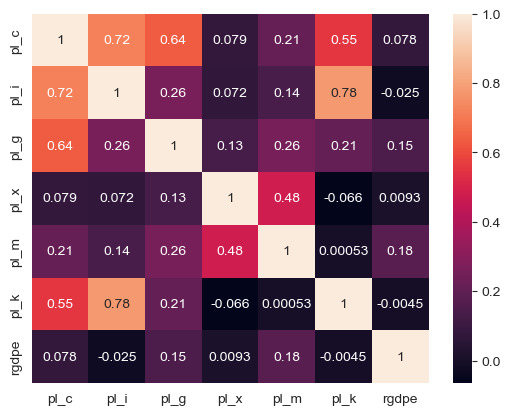

In [8]:
# heatmap看共线性
sns.heatmap(data.corr(),annot=True)

In [9]:
#拆分训练集和测试集
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x_data,y_data,test_size = 0.9,random_state=123456)

In [10]:
X_train


,pl_c,pl_i,pl_g,pl_x,pl_m,pl_k
123,0.506432,0.636209,0.248799,0.913066,0.848332,0.444221
426,0.809538,0.682921,0.894087,0.879251,0.945005,0.600652
389,1.197411,1.889088,0.483462,0.986229,0.811514,2.153801
278,1.122020,0.978285,1.324096,0.812936,0.830461,0.965968
691,0.688851,0.827331,0.604870,0.970177,0.812981,0.653448
...,...,...,...,...,...,...
568,0.642266,0.977884,0.559299,1.038710,0.976366,0.733681
49,1.341729,1.087647,1.899301,0.941202,0.879746,1.025814
498,0.553527,0.524413,0.625910,0.997681,0.650446,0.373318
746,0.661124,0.633336,0.119573,0.741246,0.753108,0.350326


<AxesSubplot:>

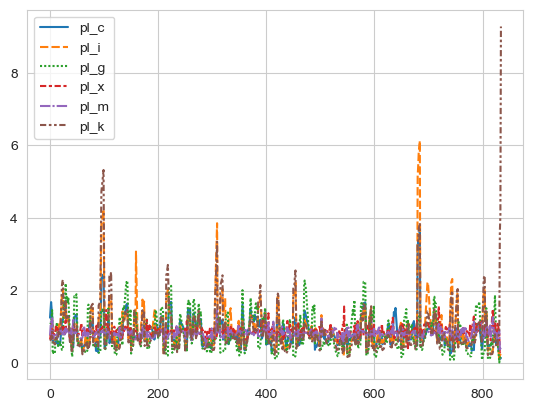

In [11]:
sns.lineplot(X_train)
